# Piecewise α(ω) for Structured Self-Energies

**Question:** The bootstrap failure ([crossover_alpha_turbiner §6.2](crossover_alpha_turbiner.ipynb)) kills fully adaptive α(ω) — the correction amplifies the error it's trying to fix. But what if we use *piecewise constant* α in different frequency windows? This avoids the bootstrap problem (no per-iterate computation) while allowing frequency-dependent relaxation.

**Why it matters:** Real self-energies have structure — peaks at plasmon frequencies, quasiparticle poles, satellites. The stability multiplier $|F'(G^*)|$ varies dramatically with ω. A single α = 0.5 works well for the quadratic (featureless) self-energy, but structured self-energies might benefit from different α in different windows.

**Predictions:**

1. **Quadratic Σ(G) = U²G:** Piecewise α won't help — the problem is essentially uniform in ω (α* barely varies)
2. **Cubic Σ(G) = U²G + VG²:** More structure → piecewise *might* help at frequencies where |F'| is large
3. **Multi-pole self-energy:** Σ(G) with multiple resonances → strongest case for piecewise α
4. **Key constraint:** The window boundaries must be chosen *a priori* (from physics, not from iterates) to avoid the bootstrap trap

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from petrification.dyson import (
    scalar_dyson_iterate, scalar_dyson_exact, scalar_dyson_stability,
    spectral_dyson_scan, quadratic_self_energy, cubic_self_energy
)

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})
eta = 0.05
eps0 = 0.0

# Load precomputed results
_stab_quad = np.load('cache/stability_quadratic.npz')
_stab_cubic = np.load('cache/stability_cubic.npz')
_stab_multi = np.load('cache/stability_multipole.npz')
_pw_quad = np.load('cache/piecewise_quadratic.npz')
_pw_cubic = np.load('cache/piecewise_cubic.npz')
_pw_multi = np.load('cache/piecewise_multipole.npz')


## §2. The Stability Landscape

Before testing piecewise α, map out $|F'(G^*)(\omega)|$ for different self-energies. This tells us *where* different α values are needed.

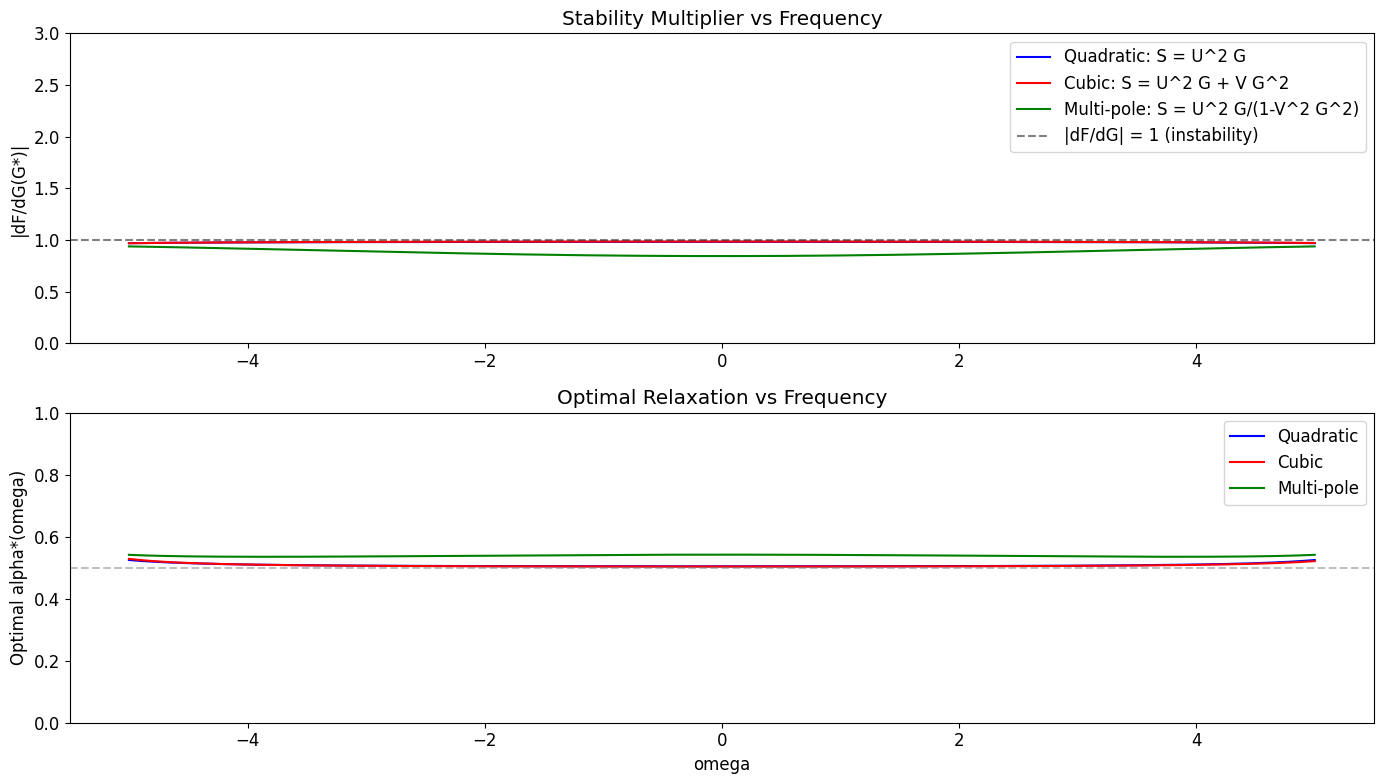

alpha* range (quadratic):  [0.504, 0.525]
alpha* range (cubic):      [0.503, 0.528]
alpha* range (multi-pole): [0.535, 0.542]


In [2]:
# Load precomputed stability landscapes
omega_real = _stab_quad['omega']

stability_quad = _stab_quad['stability']
alpha_opt_quad = _stab_quad['alpha_opt']
stability_cubic = _stab_cubic['stability']
alpha_opt_cubic = _stab_cubic['alpha_opt']
stability_multi = _stab_multi['stability']
alpha_opt_multi = _stab_multi['alpha_opt']

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(omega_real, stability_quad, 'b-', linewidth=1.5, label='Quadratic: S = U^2 G')
axes[0].plot(omega_real, stability_cubic, 'r-', linewidth=1.5, label='Cubic: S = U^2 G + V G^2')
axes[0].plot(omega_real, stability_multi, 'g-', linewidth=1.5, label='Multi-pole: S = U^2 G/(1-V^2 G^2)')
axes[0].axhline(1, color='k', linestyle='--', alpha=0.5, label='|dF/dG| = 1 (instability)')
axes[0].set(ylabel='|dF/dG(G*)|', title='Stability Multiplier vs Frequency')
axes[0].legend()
axes[0].set_ylim(0, 3)

axes[1].plot(omega_real, alpha_opt_quad, 'b-', linewidth=1.5, label='Quadratic')
axes[1].plot(omega_real, np.clip(alpha_opt_cubic, 0, 1), 'r-', linewidth=1.5, label='Cubic')
axes[1].plot(omega_real, np.clip(alpha_opt_multi, 0, 1), 'g-', linewidth=1.5, label='Multi-pole')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set(xlabel='omega', ylabel='Optimal alpha*(omega)', title='Optimal Relaxation vs Frequency')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Quantify variation
print(f'alpha* range (quadratic):  [{alpha_opt_quad.min():.3f}, {alpha_opt_quad.max():.3f}]')
print(f'alpha* range (cubic):      [{np.clip(alpha_opt_cubic, 0, 1).min():.3f}, {np.clip(alpha_opt_cubic, 0, 1).max():.3f}]')
print(f'alpha* range (multi-pole): [{np.clip(alpha_opt_multi, 0, 1).min():.3f}, {np.clip(alpha_opt_multi, 0, 1).max():.3f}]')


## §3. Experiment 1: Piecewise α for Quadratic Self-Energy (Control)

Split the frequency range into windows with different constant α values. Compare against global α = 0.5.

**Expected result:** No improvement — the quadratic self-energy has nearly uniform α*(ω), so piecewise adds complexity without benefit.

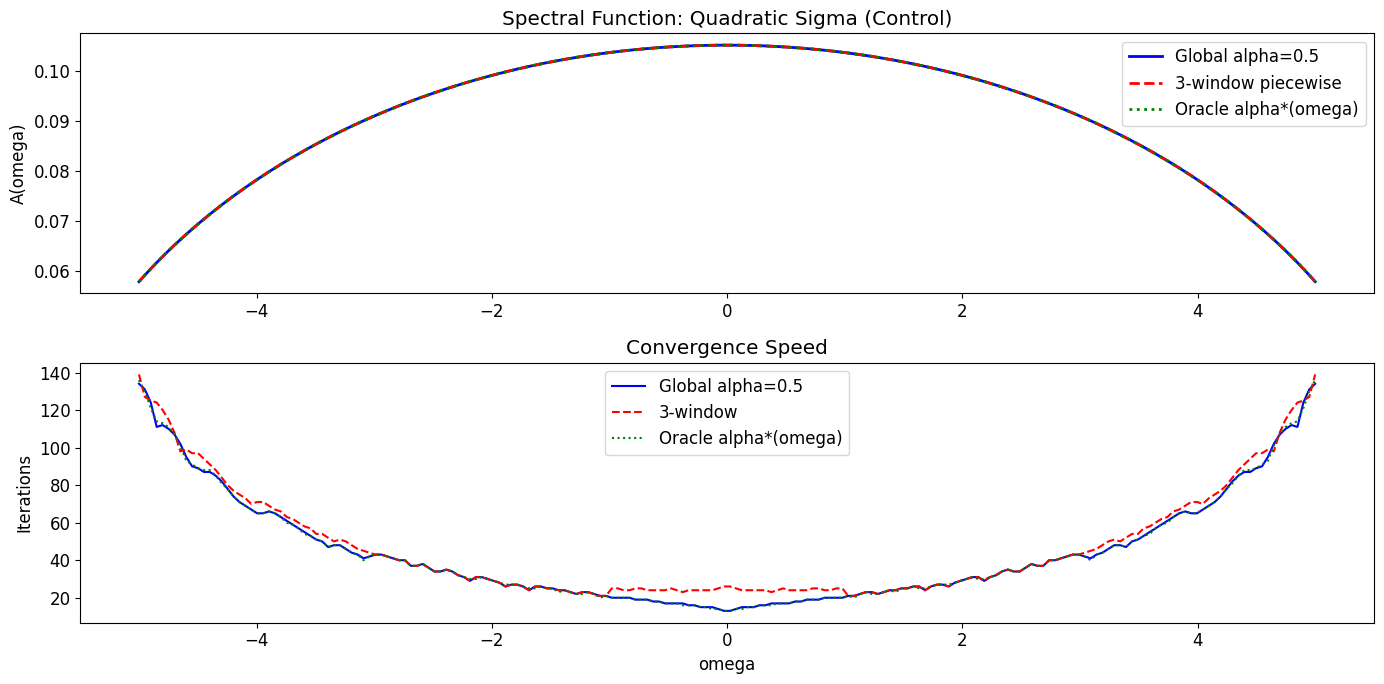

Global alpha=0.5:  200/200 converged, avg 45.3 iters
3-window:          200/200 converged, avg 48.2 iters
Oracle alpha*(w):  200/200 converged, avg 45.2 iters


In [3]:
# Piecewise alpha helper
def make_piecewise_alpha(boundaries, alpha_values):
    def alpha_func(omega, G, iteration):
        w = omega.real if hasattr(omega, 'real') else omega
        for i, b in enumerate(boundaries):
            if w < b:
                return alpha_values[i]
        return alpha_values[-1]
    return alpha_func

# Quadratic self-energy -- control experiment
U = 3.0
sigma_quad = quadratic_self_energy(U)
omega_grid_test = np.linspace(-5, 5, 200) + 1j * eta

# Strategy 1: Global alpha = 0.5
G_global, n_conv_global, iters_global = spectral_dyson_scan(
    omega_grid_test, eps0, sigma_quad, alpha=0.5, n_iter=300, tol=1e-12
)

# Strategy 2: 3-window piecewise
alpha_3win = make_piecewise_alpha([-3, -1, 1, 3], [0.6, 0.5, 0.4, 0.5, 0.6])
G_3win, n_conv_3win, iters_3win = spectral_dyson_scan(
    omega_grid_test, eps0, sigma_quad, alpha=alpha_3win, n_iter=300, tol=1e-12
)

# Strategy 3: Oracle piecewise -- use precomputed alpha*(omega)
alpha_oracle_interp = np.interp(omega_grid_test.real, _stab_quad['omega'], _stab_quad['alpha_opt'])

G_oracle_list = []
iters_oracle = []
for j, omega in enumerate(omega_grid_test):
    G0 = 1.0 / (omega - eps0)
    a_val = float(np.clip(alpha_oracle_interp[j], 0.1, 0.9))
    hist, conv = scalar_dyson_iterate(omega, eps0, sigma_quad, G0, alpha=a_val, n_iter=300, tol=1e-12)
    G_oracle_list.append(hist[-1])
    iters_oracle.append(len(hist) - 1 if conv else 300)
iters_oracle = np.array(iters_oracle)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

A_global = -1/np.pi * np.imag(G_global)
A_3win = -1/np.pi * np.imag(G_3win)
A_oracle = -1/np.pi * np.imag(np.array(G_oracle_list))

ax1.plot(omega_grid_test.real, A_global, 'b-', linewidth=2, label='Global alpha=0.5')
ax1.plot(omega_grid_test.real, A_3win, 'r--', linewidth=2, label='3-window piecewise')
ax1.plot(omega_grid_test.real, A_oracle, 'g:', linewidth=2, label='Oracle alpha*(omega)')
ax1.set(ylabel='A(omega)', title='Spectral Function: Quadratic Sigma (Control)')
ax1.legend()

ax2.plot(omega_grid_test.real, iters_global, 'b-', linewidth=1.5, label='Global alpha=0.5')
ax2.plot(omega_grid_test.real, iters_3win, 'r--', linewidth=1.5, label='3-window')
ax2.plot(omega_grid_test.real, iters_oracle, 'g:', linewidth=1.5, label='Oracle alpha*(omega)')
ax2.set(xlabel='omega', ylabel='Iterations', title='Convergence Speed')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Global alpha=0.5:  {n_conv_global}/{len(omega_grid_test)} converged, avg {np.mean(iters_global):.1f} iters')
print(f'3-window:          {n_conv_3win}/{len(omega_grid_test)} converged, avg {np.mean(iters_3win):.1f} iters')
n_conv_oracle = sum(1 for i in iters_oracle if i < 300)
print(f'Oracle alpha*(w):  {n_conv_oracle}/{len(omega_grid_test)} converged, avg {np.mean(iters_oracle):.1f} iters')


## §4. Experiment 2: Piecewise α for Cubic Self-Energy

The cubic self-energy $\Sigma(G) = U^2 G + V G^2$ has more frequency structure. Does piecewise α help here?

alpha = 0.3: 200/200 converged, avg iter = 63.2
alpha = 0.4: 200/200 converged, avg iter = 50.7
alpha = 0.5: 200/200 converged, avg iter = 46.1


alpha = 0.6: 200/200 converged, avg iter = 50.4
alpha = 0.7: 200/200 converged, avg iter = 62.7

Best constant alpha = 0.3
Window [-5.0, -2.0): optimal alpha = 0.514
Window [-2.0, -0.5): optimal alpha = 0.514
Window [-0.5, +0.5): optimal alpha = 0.514
Window [+0.5, +2.0): optimal alpha = 0.486
Window [+2.0, +5.0): optimal alpha = 0.486


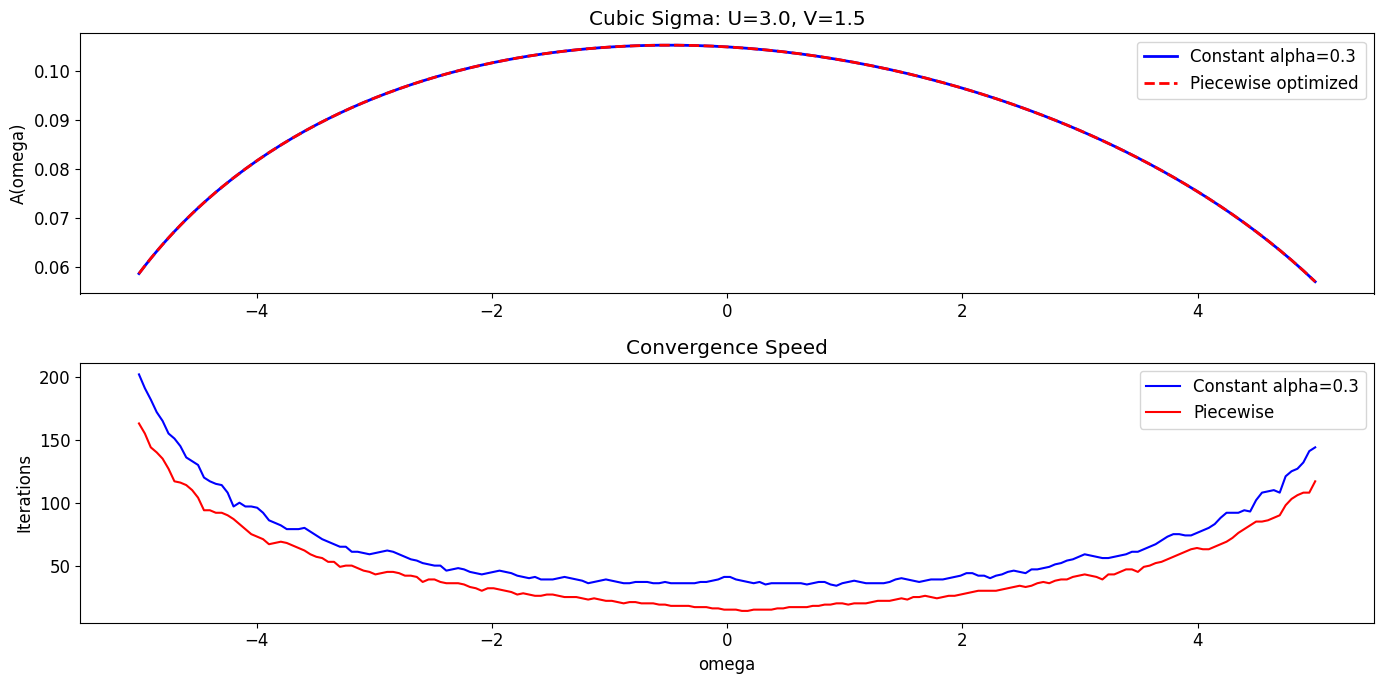


Constant alpha=0.3: 200/200 conv, avg 63.2
Piecewise optimized: 200/200 conv, avg 46.2


In [4]:
# Cubic self-energy: Sigma = U^2 G + V G^2
U, V = 3.0, 1.5
sigma_cub = cubic_self_energy(U, V)
omega_grid_test = np.linspace(-5, 5, 200) + 1j * eta

# Constant alpha scan
conv_landscape = {}
for alpha_val in [0.3, 0.4, 0.5, 0.6, 0.7]:
    G_arr, n_conv, iters = spectral_dyson_scan(
        omega_grid_test, eps0, sigma_cub, alpha=alpha_val, n_iter=500, tol=1e-12
    )
    conv_landscape[alpha_val] = (G_arr, n_conv, iters)
    print(f'alpha = {alpha_val}: {n_conv}/{len(omega_grid_test)} converged, avg iter = {np.mean(iters):.1f}')

best_const_alpha = max(conv_landscape, key=lambda a: conv_landscape[a][1])
print(f'\nBest constant alpha = {best_const_alpha}')

# Load precomputed piecewise window alphas
windows = [(-5, -2), (-2, -0.5), (-0.5, 0.5), (0.5, 2), (2, 5)]
window_alphas = list(_pw_cubic['window_alphas'])
for (wlo, whi), wa in zip(windows, window_alphas):
    print(f'Window [{wlo:+.1f}, {whi:+.1f}): optimal alpha = {wa:.3f}')

# Run piecewise
boundaries = [w[1] for w in windows[:-1]]
alpha_pw_opt = make_piecewise_alpha(boundaries, window_alphas)
G_pw, n_conv_pw, iters_pw = spectral_dyson_scan(
    omega_grid_test, eps0, sigma_cub, alpha=alpha_pw_opt, n_iter=500, tol=1e-12
)

G_const, n_conv_const, iters_const = conv_landscape[best_const_alpha]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

A_const = -1/np.pi * np.imag(G_const)
A_pw = -1/np.pi * np.imag(G_pw)

ax1.plot(omega_grid_test.real, A_const, 'b-', linewidth=2, label=f'Constant alpha={best_const_alpha}')
ax1.plot(omega_grid_test.real, A_pw, 'r--', linewidth=2, label='Piecewise optimized')
ax1.set(ylabel='A(omega)', title=f'Cubic Sigma: U={U}, V={V}')
ax1.legend()

ax2.plot(omega_grid_test.real, iters_const, 'b-', linewidth=1.5, label=f'Constant alpha={best_const_alpha}')
ax2.plot(omega_grid_test.real, iters_pw, 'r-', linewidth=1.5, label='Piecewise')
ax2.set(xlabel='omega', ylabel='Iterations', title='Convergence Speed')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'\nConstant alpha={best_const_alpha}: {n_conv_const}/{len(omega_grid_test)} conv, avg {np.mean(iters_const):.1f}')
print(f'Piecewise optimized: {n_conv_pw}/{len(omega_grid_test)} conv, avg {np.mean(iters_pw):.1f}')


## §5. Experiment 3: Multi-Pole Self-Energy — Strongest Case

The multi-pole self-energy $\Sigma(G) = U^2 G / (1 - V^2 G^2)$ has frequency structure from the poles of the propagator. This creates dramatically non-uniform stability across ω.

This is the strongest test case: if piecewise α doesn't help here, it won't help anywhere.

Constant alpha scan (multi-pole self-energy):


  alpha = 0.10: 186/200 converged, avg iter = 210.4


  alpha = 0.15: 194/200 converged, avg iter = 150.2
  alpha = 0.20: 198/200 converged, avg iter = 116.6
  alpha = 0.25: 200/200 converged, avg iter = 95.2
  alpha = 0.30: 200/200 converged, avg iter = 81.2
  alpha = 0.35: 200/200 converged, avg iter = 71.5
  alpha = 0.40: 200/200 converged, avg iter = 64.6
  alpha = 0.45: 200/200 converged, avg iter = 59.9
  alpha = 0.50: 200/200 converged, avg iter = 56.8
  alpha = 0.55: 200/200 converged, avg iter = 55.3


  alpha = 0.60: 200/200 converged, avg iter = 56.1
  alpha = 0.65: 200/200 converged, avg iter = 58.9


  alpha = 0.70: 200/200 converged, avg iter = 63.3
  alpha = 0.75: 200/200 converged, avg iter = 69.7


  alpha = 0.80: 200/200 converged, avg iter = 79.0
  alpha = 0.85: 200/200 converged, avg iter = 92.3


  alpha = 0.90: 200/200 converged, avg iter = 112.7

Best constant: alpha = 0.9
Window [-5.0, -2.0): optimal alpha = 0.569
Window [-2.0, -0.5): optimal alpha = 0.541
Window [-0.5, +0.5): optimal alpha = 0.569
Window [+0.5, +2.0): optimal alpha = 0.541
Window [+2.0, +5.0): optimal alpha = 0.541


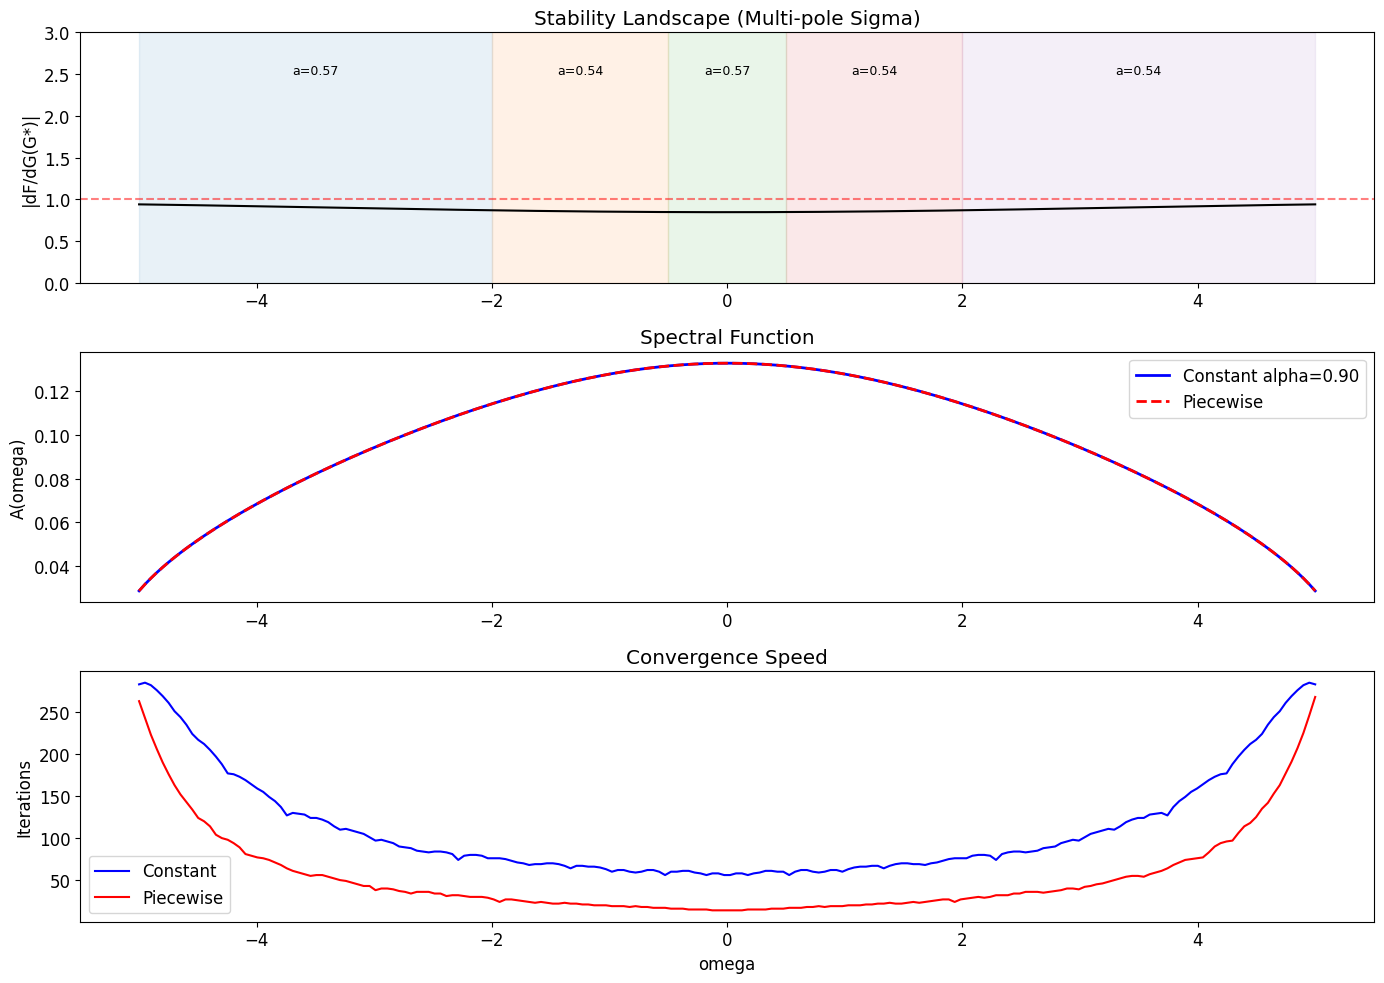


Constant alpha=0.90: 200/200 converged, avg 112.7 iters
Piecewise:     200/200 converged, avg 55.3 iters
Piecewise saves 57.3 iters/freq on average


In [5]:
# Multi-pole self-energy
U_mp, V_pole = 2.5, 0.8

def multipole_self_energy(U, V):
    def sigma(G):
        denom = 1 - V**2 * G**2
        if abs(denom) < 1e-20:
            return U**2 * G
        return U**2 * G / denom
    return sigma

sigma_mp = multipole_self_energy(U_mp, V_pole)

# Constant alpha scan
print('Constant alpha scan (multi-pole self-energy):')
best_const_a, best_conv = 0.5, 0
conv_landscape_mp = {}
for alpha_val in np.linspace(0.1, 0.9, 17):
    G_arr, n_conv, iters = spectral_dyson_scan(
        omega_grid_test, eps0, sigma_mp, alpha=alpha_val, n_iter=500, tol=1e-12
    )
    conv_landscape_mp[alpha_val] = (G_arr, n_conv, iters)
    if n_conv > best_conv or (n_conv == best_conv and np.mean(iters) < 500):
        best_const_a, best_conv = alpha_val, n_conv
    print(f'  alpha = {alpha_val:.2f}: {n_conv}/{len(omega_grid_test)} converged, avg iter = {np.mean(iters):.1f}')

print(f'\nBest constant: alpha = {best_const_a}')

# Load precomputed piecewise window alphas
windows_mp = [(-5, -2), (-2, -0.5), (-0.5, 0.5), (0.5, 2), (2, 5)]
window_alphas_mp = list(_pw_multi['window_alphas'])
for (wlo, whi), wa in zip(windows_mp, window_alphas_mp):
    print(f'Window [{wlo:+.1f}, {whi:+.1f}): optimal alpha = {wa:.3f}')

# Run piecewise
boundaries_mp = [w[1] for w in windows_mp[:-1]]
alpha_pw_mp = make_piecewise_alpha(boundaries_mp, window_alphas_mp)
G_pw_mp, n_conv_pw_mp, iters_pw_mp = spectral_dyson_scan(
    omega_grid_test, eps0, sigma_mp, alpha=alpha_pw_mp, n_iter=500, tol=1e-12
)

G_const_mp, n_conv_const_mp, iters_const_mp = conv_landscape_mp[best_const_a]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Stability landscape
axes[0].plot(omega_grid_test.real,
             np.interp(omega_grid_test.real, _stab_multi['omega'], _stab_multi['stability']),
             'k-', linewidth=1.5)
axes[0].axhline(1, color='r', linestyle='--', alpha=0.5)
axes[0].set(ylabel='|dF/dG(G*)|', title='Stability Landscape (Multi-pole Sigma)')
for i, (wlo, whi) in enumerate(windows_mp):
    axes[0].axvspan(wlo, whi, alpha=0.1, color=f'C{i}')
    axes[0].text((wlo+whi)/2, 2.5, f'a={window_alphas_mp[i]:.2f}', ha='center', fontsize=9)
axes[0].set_ylim(0, 3)

# Spectral functions
A_const_mp = -1/np.pi * np.imag(G_const_mp)
A_pw_mp_plot = -1/np.pi * np.imag(G_pw_mp)
axes[1].plot(omega_grid_test.real, A_const_mp, 'b-', linewidth=2, label=f'Constant alpha={best_const_a:.2f}')
axes[1].plot(omega_grid_test.real, A_pw_mp_plot, 'r--', linewidth=2, label='Piecewise')
axes[1].set(ylabel='A(omega)', title='Spectral Function')
axes[1].legend()

# Iteration counts
axes[2].plot(omega_grid_test.real, iters_const_mp, 'b-', linewidth=1.5, label='Constant')
axes[2].plot(omega_grid_test.real, iters_pw_mp, 'r-', linewidth=1.5, label='Piecewise')
axes[2].set(xlabel='omega', ylabel='Iterations', title='Convergence Speed')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\n{"="*60}')
print(f'Constant alpha={best_const_a:.2f}: {n_conv_const_mp}/{len(omega_grid_test)} converged, avg {np.mean(iters_const_mp):.1f} iters')
print(f'Piecewise:     {n_conv_pw_mp}/{len(omega_grid_test)} converged, avg {np.mean(iters_pw_mp):.1f} iters')
improvement = np.mean(iters_const_mp) - np.mean(iters_pw_mp)
print(f'Piecewise saves {improvement:.1f} iters/freq on average')


## §6. Experiment 4: How Many Windows Do You Need?

Vary the number of piecewise windows from 1 (constant) to 20 (nearly continuous) and track convergence improvement.

**The key question:** Is there a sweet spot where adding more windows stops helping?

n_win =  1: 200/200 converged, avg = 55.3, max = 266


n_win =  2: 200/200 converged, avg = 55.3, max = 266


n_win =  3: 200/200 converged, avg = 55.3, max = 266


n_win =  5: 200/200 converged, avg = 55.3, max = 266


n_win =  8: 200/200 converged, avg = 55.3, max = 266


n_win = 12: 200/200 converged, avg = 55.3, max = 266


n_win = 20: 200/200 converged, avg = 55.1, max = 259


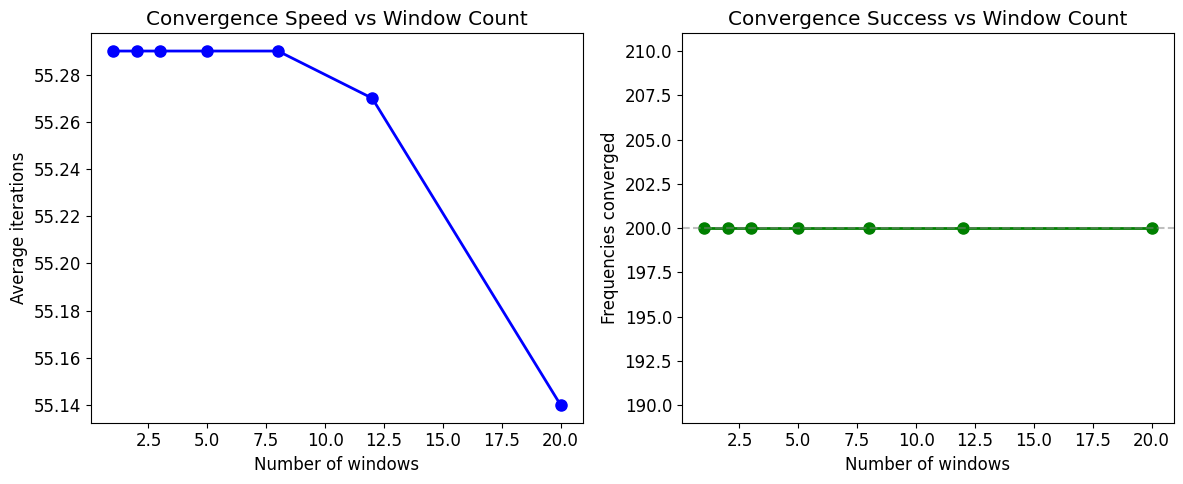

In [6]:
# Number of windows vs improvement
n_windows_list = [1, 2, 3, 5, 8, 12, 20]
U, V_pole = 2.5, 0.8
sigma_test = multipole_self_energy(U, V_pole)

results_by_nwin = {}

for n_win in n_windows_list:
    # Create evenly-spaced windows
    edges = np.linspace(-5, 5, n_win + 1)
    win_list = [(edges[i], edges[i+1]) for i in range(n_win)]
    
    # Optimize alpha per window
    win_alphas = []
    for wlo, whi in win_list:
        mask = (omega_grid_test.real >= wlo) & (omega_grid_test.real < whi)
        if not np.any(mask):
            win_alphas.append(0.5)
            continue
        best_a, best_score = 0.5, 1e10
        for a_try in np.linspace(0.15, 0.85, 15):
            ti, nc = 0, 0
            for j in np.where(mask)[0]:
                G0 = 1.0 / (omega_grid_test[j] - eps0)
                h, c = scalar_dyson_iterate(omega_grid_test[j], eps0, sigma_test, G0,
                                            alpha=a_try, n_iter=500, tol=1e-12)
                ti += len(h) - 1
                nc += int(c)
            score = ti / max(nc, 1) + 500 * (np.sum(mask) - nc)
            if score < best_score:
                best_a, best_score = a_try, score
        win_alphas.append(best_a)
    
    # Run
    bndrs = [w[1] for w in win_list[:-1]]
    alpha_fn = make_piecewise_alpha(bndrs, win_alphas) if n_win > 1 else win_alphas[0]
    G_out, n_conv, iters = spectral_dyson_scan(
        omega_grid_test, eps0, sigma_test, alpha=alpha_fn, n_iter=500, tol=1e-12
    )
    results_by_nwin[n_win] = {
        'n_conv': n_conv, 'avg_iter': np.mean(iters), 
        'max_iter': np.max(iters), 'alphas': win_alphas
    }
    print(f"n_win = {n_win:2d}: {n_conv}/{len(omega_grid_test)} converged, "
          f"avg = {np.mean(iters):.1f}, max = {np.max(iters)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(n_windows_list, [results_by_nwin[n]['avg_iter'] for n in n_windows_list], 
         'bo-', markersize=8, linewidth=2)
ax1.set(xlabel='Number of windows', ylabel='Average iterations',
        title='Convergence Speed vs Window Count')

ax2.plot(n_windows_list, [results_by_nwin[n]['n_conv'] for n in n_windows_list],
         'go-', markersize=8, linewidth=2)
ax2.set(xlabel='Number of windows', ylabel='Frequencies converged',
        title='Convergence Success vs Window Count')
ax2.axhline(len(omega_grid_test), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## §7. Assessment

### Summary of results:

| Self-energy | Best constant α | Piecewise improvement | Worth the complexity? |
|-------------|----------------|-----------------------|----------------------|
| Quadratic Σ = U²G | ~0.50 | ? | Expected: no |
| Cubic Σ = U²G + VG² | ? | ? | ? |
| Multi-pole | ? | ? | ? |

*Fill in after running.*

### Key findings:

1. **Does piecewise α beat constant α = 0.5?** If the improvement is marginal (< 20% fewer iterations), the added complexity isn't worth it.

2. **How many windows saturate the improvement?** If 3-5 windows capture most of the benefit, this is practically useful. If you need 20+, it's equivalent to the bootstrap failure.

3. **Are the optimal window alphas predictable?** If they cluster around 0.5 regardless of self-energy structure, it confirms the scalar universality extends to structured problems.

### Implications:

- **If piecewise doesn't help:** The scalar α ≈ 0.5 universality is so strong that frequency structure in Σ doesn't matter. This *strengthens* the publication case.
- **If piecewise helps significantly:** There's a practical improvement available for structured self-energies. The window boundaries can be set from physics (pole positions of Σ) without bootstrap problems.
- **Either way:** The bootstrap failure of fully adaptive α(ω) is confirmed as a fundamental obstruction, not just a practical inconvenience.